# Network Anomaly Detection using NSL-KDD Dataset

This notebook builds a Machine Learning based Network Intrusion Detection System using the NSL-KDD dataset and Random Forest Classifier.

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

## 2. Define NSL-KDD Column Names
The NSL-KDD dataset does not include column headers, so we manually define all 43 feature names.

In [3]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins",
"logged_in","num_compromised","root_shell","su_attempted","num_root",
"num_file_creations","num_shells","num_access_files",
"num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate",
"srv_rerror_rate","same_srv_rate","diff_srv_rate",
"srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate",
"label","difficulty"
]

## 3. Load Training and Testing Dataset

In [4]:
train_df = pd.read_csv(
    "../data/NSL-KDD/KDDTrain+.txt",
    names=columns
)

test_df = pd.read_csv(
    "../data/NSL-KDD/KDDTest-21.txt",
    names=columns
)

## 4. Dataset Shape Verification

In [5]:
print(train_df.shape)
print(test_df.shape)

(125973, 43)
(11850, 43)


## 5. Preview Dataset

In [6]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 6. Missing Value Analysis

In [8]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

## 7. Drop Unnecessary Column
The `difficulty` column is removed because it is not required for binary classification.

In [9]:
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

print(train_df.shape)
print(test_df.shape)

(125973, 42)
(11850, 42)


## 8. Attack Class Distribution

In [10]:
train_df["label"].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

## 9. Binary Label Conversion
Normal traffic is encoded as `0` and all attack traffic is encoded as `1`.

In [11]:
train_df["label"] = train_df["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_df["label"] = test_df["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

In [12]:
print(train_df["label"].value_counts())
print()
print(test_df["label"].value_counts())

label
0    67343
1    58630
Name: count, dtype: int64

label
1    9698
0    2152
Name: count, dtype: int64


## 10. Encoding Categorical Features
The categorical columns `protocol_type`, `service`, and `flag` are encoded using Label Encoding.

In [13]:
categorical_cols = [
    "protocol_type",
    "service",
    "flag"
]

encoder = LabelEncoder()

for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.transform(test_df[col])

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  int64  
 2   service                      125973 non-null  int64  
 3   flag                         125973 non-null  int64  
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

## 11. Train-Test Split
A stratified train-test split is applied to preserve class distribution.

In [20]:
from sklearn.model_selection import train_test_split

X = train_df.drop("label", axis=1)
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(100778, 41)
(25195, 41)


## 12. Random Forest Model Training
Random Forest is used because it handles nonlinear feature interactions and performs well on intrusion detection datasets.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=25,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=300, n_jobs=-1, random_state=42)

## 13. Model Prediction

In [24]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

## 14. Accuracy Evaluation

In [18]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", train_acc)

Training Accuracy : 0.9996665952227858


In [25]:
test_acc = accuracy_score(y_test, test_pred)

print("Testing Accuracy :", test_acc)

Testing Accuracy : 0.9990871204604088


## 15. Precision, Recall and F1 Score

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision :", precision_score(y_test, test_pred))
print("Recall :", recall_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))

Precision : 0.9994878361075544
Recall : 0.9985502302575473
F1 Score : 0.9990188131905635


## 16. Classification Report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



## 17. Confusion Matrix

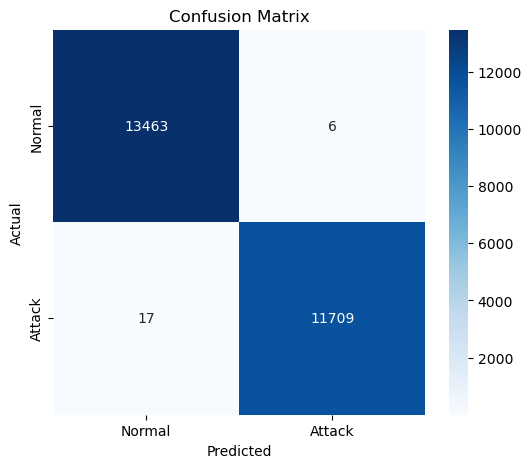

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

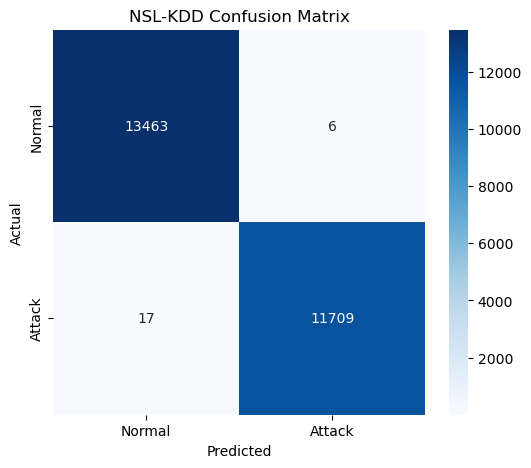

NSL-KDD confusion matrix PNG saved!


In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../reports", exist_ok=True)

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("NSL-KDD Confusion Matrix")

plt.savefig("../reports/nsl-kdd_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("NSL-KDD confusion matrix PNG saved!")

## 18. ROC-AUC Score

In [32]:
from sklearn.metrics import roc_auc_score

probs = rf_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, probs)

print("ROC-AUC Score :", roc)

ROC-AUC Score : 0.9999923197464436


## 19. ROC Curve Visualization

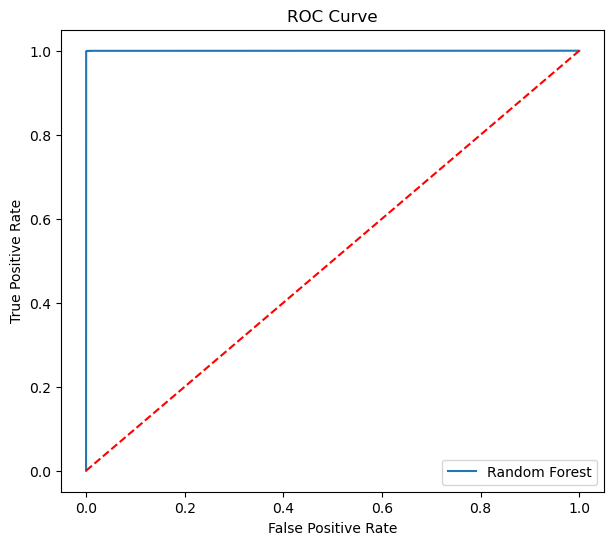

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

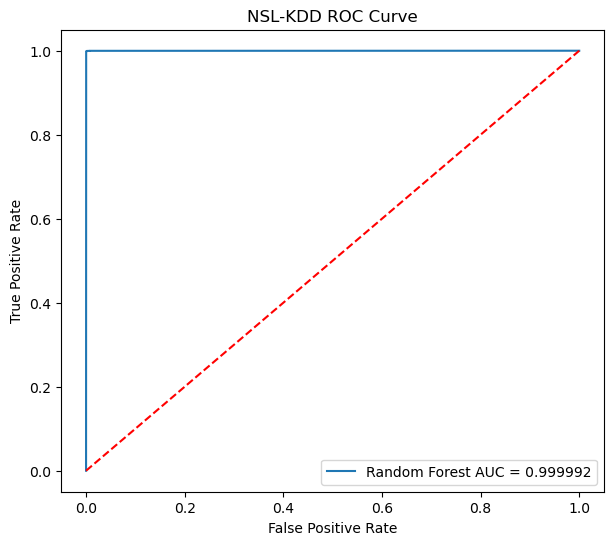

NSL-KDD ROC curve PNG saved!


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc = roc_auc_score(y_test, probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {roc:.6f}")
plt.plot([0,1], [0,1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("NSL-KDD ROC Curve")
plt.legend()

plt.savefig("../reports/nsl-kdd_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("NSL-KDD ROC curve PNG saved!")

## 20. Feature Importance Analysis

In [29]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,src_bytes,0.190693
5,dst_bytes,0.102348
3,flag,0.085663
28,same_srv_rate,0.080383
33,dst_host_same_srv_rate,0.059100
32,dst_host_srv_count,0.058947
29,diff_srv_rate,0.050530
11,logged_in,0.043073
34,dst_host_diff_srv_rate,0.037139
1,protocol_type,0.036651


## 23. Feature Importance Visualization

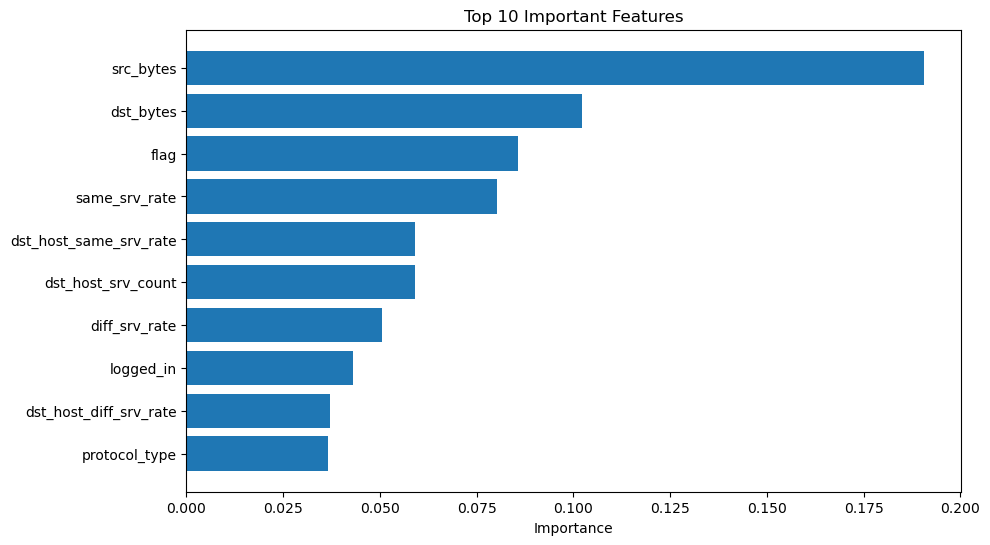

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()

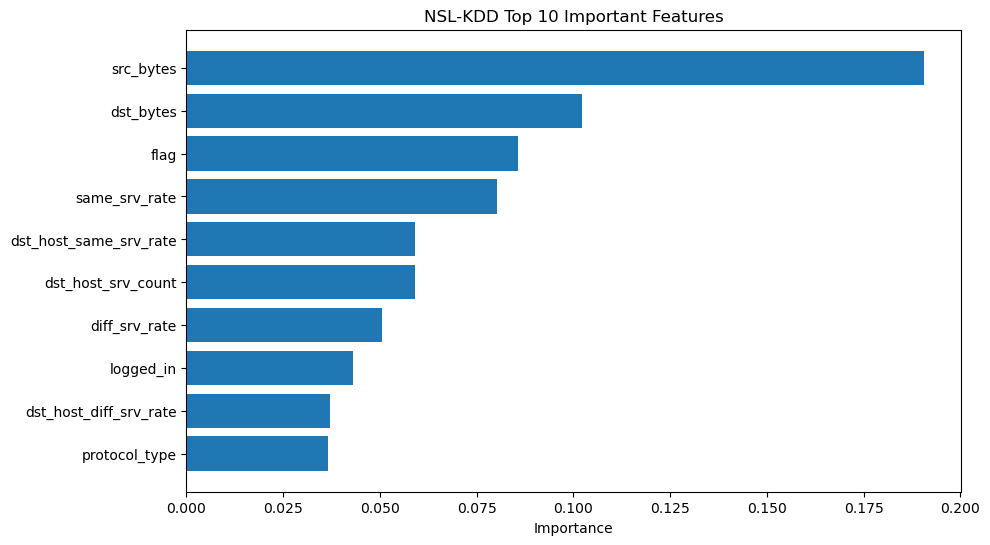

NSL-KDD feature importance PNG saved!


In [39]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()
plt.title("NSL-KDD Top 10 Important Features")
plt.xlabel("Importance")

plt.savefig("../reports/nsl-kdd_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("NSL-KDD feature importance PNG saved!")

## 21. Save Trained Model

In [34]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model, "../models/nls-kdd_anomaly_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


## 22. Save Label Encoder

In [36]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(encoder, "../models/nsl-kdd_label_encoder.pkl")

print("NSL-KDD label encoder saved successfully!")

NSL-KDD label encoder saved successfully!


## 23. Save Model Metrics Report

In [35]:
report = classification_report(y_test, test_pred)

os.makedirs("../reports", exist_ok=True)

with open("../reports/nsl-kdd_model_metrics.txt","w") as f:

    f.write("Network Intrusion Detection System\n\n")

    f.write(f"Training Accuracy : {train_acc}\n")
    f.write(f"Testing Accuracy : {test_acc}\n\n")

    f.write(report)

print("Metrics Saved Successfully!")

Metrics Saved Successfully!
